# Xavier Normal Wieight Initialization

## Importing Libraries

In [103]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons

## Loading the Dataset

In [104]:
X, y = make_moons(100, noise=0.1, random_state=0)

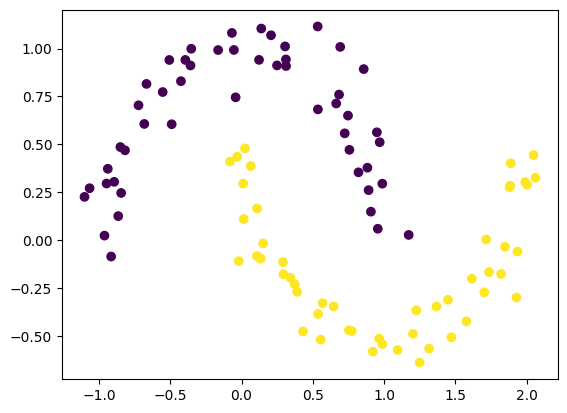

In [105]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

## Model Building with Xavier Normal Initialization

In [106]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(10, activation='tanh'),
        keras.layers.Dense(10, activation='tanh'),
        keras.layers.Dense(10, activation='tanh'),
        keras.layers.Dense(10, activation='tanh'),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)

In [107]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model.get_weights()

[array([[-0.4047854 ,  0.39877254,  0.00919831, -0.23273033, -0.16280651,
          0.6052788 , -0.36036414, -0.1741184 , -0.04544526,  0.01437306],
        [-0.10121077, -0.3313489 ,  0.41718465,  0.26234084, -0.16626209,
          0.06131846, -0.583543  , -0.0403775 ,  0.56370765,  0.45414203]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.48102775, -0.3366723 , -0.14303598, -0.45694068,  0.03654969,
          0.48932266,  0.5042256 ,  0.47433674, -0.01897836,  0.4296354 ],
        [-0.109669  , -0.15026098,  0.09616154,  0.14464355,  0.271567  ,
          0.31911802, -0.1485849 , -0.40505522,  0.02681231,  0.36904633],
        [ 0.01916432, -0.20007583, -0.3565195 , -0.08416817,  0.23879522,
         -0.37469774, -0.33432305,  0.28443545, -0.09422666, -0.46062115],
        [-0.51537794,  0.07082921,  0.33543122,  0.36173034,  0.29141796,
         -0.29891485,  0.23560625, -0.5311458 ,  0.09555107, -0.26574033],
        [-0.33671

In [109]:
len(model.get_weights())

10

In [110]:
initial_weights = model.get_weights()

In [111]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [112]:
model.set_weights(initial_weights)

In [113]:
model.get_weights()

[array([[ 0.60196537, -0.738597  , -0.3885356 , -0.02968646,  1.1624411 ,
          0.72451085, -0.15394142, -1.0319979 ,  0.2577692 , -0.5650293 ],
        [-0.06217422,  0.04944145,  0.47582367,  0.02389362, -0.70444   ,
         -0.20260526,  0.88329965, -0.30011147,  1.4332464 , -0.68646044]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.24679148, -0.25550783, -0.17485781,  0.14453402, -0.22720455,
         -0.07663815, -0.3898944 ,  0.527762  ,  0.06184072, -0.34714365],
        [ 0.12401802,  0.5191793 ,  0.02886221, -0.23735277, -0.5485774 ,
         -0.10814884,  0.03332043, -0.04717154, -0.44770113,  0.7504356 ],
        [-0.22437379, -0.0421813 , -0.34171906,  0.0197376 ,  0.0086505 ,
          0.28720963,  0.16945691, -0.08219719, -0.16672982,  0.02731065],
        [ 0.35169697, -0.44249567, -0.20523006, -0.01983819, -0.32758233,
         -0.4780844 ,  0.3010957 , -0.59726375, -0.5352106 , -0.04795919],
        [ 0.22385

In [114]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam()
)

In [115]:
model.get_weights()

[array([[ 0.60196537, -0.738597  , -0.3885356 , -0.02968646,  1.1624411 ,
          0.72451085, -0.15394142, -1.0319979 ,  0.2577692 , -0.5650293 ],
        [-0.06217422,  0.04944145,  0.47582367,  0.02389362, -0.70444   ,
         -0.20260526,  0.88329965, -0.30011147,  1.4332464 , -0.68646044]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.24679148, -0.25550783, -0.17485781,  0.14453402, -0.22720455,
         -0.07663815, -0.3898944 ,  0.527762  ,  0.06184072, -0.34714365],
        [ 0.12401802,  0.5191793 ,  0.02886221, -0.23735277, -0.5485774 ,
         -0.10814884,  0.03332043, -0.04717154, -0.44770113,  0.7504356 ],
        [-0.22437379, -0.0421813 , -0.34171906,  0.0197376 ,  0.0086505 ,
          0.28720963,  0.16945691, -0.08219719, -0.16672982,  0.02731065],
        [ 0.35169697, -0.44249567, -0.20523006, -0.01983819, -0.32758233,
         -0.4780844 ,  0.3010957 , -0.59726375, -0.5352106 , -0.04795919],
        [ 0.22385

In [116]:
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.5345 - val_loss: 0.4022
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4994 - val_loss: 0.3907
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5160 - val_loss: 0.3805
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.5150 - val_loss: 0.3701
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5146 - val_loss: 0.3597
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4903 - val_loss: 0.3492
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4959 - val_loss: 0.3391
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4737 - val_loss: 0.3289
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4629 - val_loss: 0.3191
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4388 - val_loss: 0.3095
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4539 - val_loss: 0.3002
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4512 - val_l

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


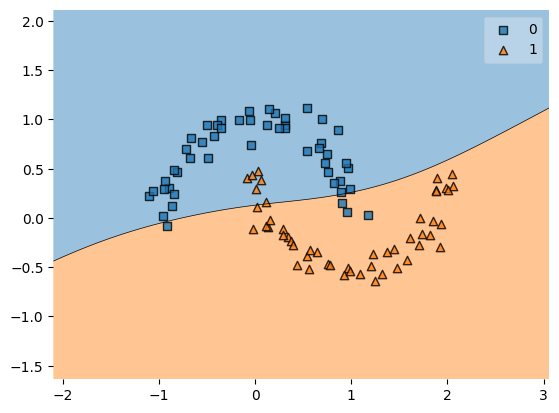

In [117]:
plot_decision_regions(X, y, clf=model)
plt.show()